# 🟢 **Import**

In [102]:
import os
import json
import time
import yaml
import sys
import math
import pandas as pd
import matplotlib.pyplot as plt
import torch
import pickle
import random
import numpy as np

from tqdm import tqdm
from itertools import cycle
from datetime import datetime
from dataclasses import dataclass, asdict
from prettytable import PrettyTable
from tokenizers import Tokenizer
from torch.utils.data import Dataset, DataLoader
from torch import nn
from torch.nn import functional as F
from torchmetrics.aggregation import MeanMetric

# 🟢 **Utils**

In [103]:
def prepare_data(tokens, seq_len):
    if not isinstance(tokens, torch.Tensor):
        tokens = torch.tensor(tokens, dtype=torch.long)

    n_tokens = tokens.shape[0]

    if n_tokens < seq_len:
        print(f"⚠️ Number of tokens ({n_tokens}) it is less than seq_len={seq_len}.")
        return tokens.unsqueeze(0)

    n_tokens = (n_tokens // seq_len) * seq_len
    tokens = tokens[:n_tokens]
    return tokens.view(-1, seq_len)

In [104]:
def num_trainable_params(model):
  nums = sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6
  return nums

In [105]:
# Benchmarking function
def calculate_time(model, x, num_runs=10):
    start = time.time()
    for _ in range(num_runs):
        model(x)
    return (time.time() - start) / num_runs

# 🟢 **Dataset**

In [106]:
class Alphabet_NLP_Dataset(Dataset):
    def __init__(self, data, seq_len):
        self.seq_len = seq_len
        data = np.array(data, dtype=np.int64)
        self.data = prepare_data(data, seq_len+1)

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        sample = torch.tensor(self.data[idx], dtype=torch.long)
        return sample

# 🟢 **Model**

## 🔴 Multi-Head Attention

In [107]:
class MultiHeadAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.n_embd = config.n_embd
        self.n_head = config.n_head
        self.head_size = self.n_embd // self.n_head

        self.qkv_proj = nn.Linear(self.n_embd, 3*self.n_embd, bias=False)
        self.c_proj = nn.Linear(self.n_embd, self.n_embd, bias=False)
        self.c_proj.residual = True

    def forward(self, x):
        B, T, C = x.shape
        # QKV linear
        q, k, v = self.qkv_proj(x).view(B, T, 3*self.n_head, self.head_size).transpose(1, 2).chunk(3, dim=-3)
        # Scaled Dot Product Attention using pytorch
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        # Reshape and final projection
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.c_proj(y)
        return y

## 🔴 Feed Forward (MLP)

In [108]:
class FeedForward(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.n_embd = config.n_embd
        self.f_expnd = config.f_expnd

        self.up_proj = nn.Linear(self.n_embd, int(self.f_expnd*self.n_embd), bias=False)
        self.down_proj = nn.Linear(int(self.f_expnd*self.n_embd), self.n_embd, bias=False)
        self.down_proj.residual = True
        self.mlp_dropout = nn.Dropout(config.dropout_rate)

    def forward(self, x):
        return self.mlp_dropout(self.down_proj(F.gelu(self.up_proj(x))))

## 🔴 Decoder Block

In [109]:
class DecoderBlock(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.n_embd = config.n_embd
        # Multi Head Attention
        self.ln1 = nn.LayerNorm(config.n_embd)
        self.mha = MultiHeadAttention(config)
        # Feed Forward Neural Network
        self.ln2 = nn.LayerNorm(config.n_embd)
        self.mlp = FeedForward(config)
        self.dropout = nn.Dropout(config.dropout_rate)

    def forward(self, x):
        x = x + self.dropout(self.mha(self.ln1(x)))
        x = x + self.dropout(self.mlp(self.ln2(x)))
        return x

## 🔴 ARK

In [110]:
class ARK(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config
        self.wte = nn.Embedding(config.vocab_size, config.n_embd) # Token embedding
        self.wpe = nn.Embedding(config.max_seq_len, config.n_embd) # Position embedding
        self.decoders = nn.ModuleList([DecoderBlock(config) for _ in range(config.n_layer)]) # Decoders
        self.lnf = nn.LayerNorm(config.n_embd)
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False) # Classifier
        self.lm_head.weight = self.wte.weight # Weight tying

        self.apply(self._init_weights)

    def _init_weights(self, module):
        std = 0.02
        if isinstance(module, nn.Linear):
            if hasattr(module, 'residual'):
                std *= (2*self.config.n_layer)**-0.5
            nn.init.normal_(module.weight, mean=0.0, std=std)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=std)

    def forward(self, idx):
        B, T = idx.shape
        # Token Embedding + Position Embedding
        x = self.wte(idx) + self.wpe(torch.arange(T, device=idx.device))
        # Decoders
        for decoder in self.decoders:
            x = decoder(x)
        # Classifier
        x = self.lnf(x)
        logits = self.lm_head(x)
        return logits

# 🟢 **Config**

In [111]:
@dataclass
class DatasetConfig:
    train_path: str
    valid_path: str
    tokenizer_path: str
    batch_size: int = 32
    seq_len: int = 128


@dataclass
class ARKConfig:
    vocab_size: int = 50257
    max_seq_len: int = 1024
    n_layer: int = 4
    n_head: int = 4
    n_embd: int = 64
    f_expnd: int = 4
    dropout_rate: float = 0.2


@dataclass
class OptimizerConfig:
    max_lr: float = 3e-4
    betas: tuple = (0.9, 0.95)
    weight_decay: float = 0.1
    fused: bool = True
    warmup_steps: int = 100
    alpha: float = 0.1


@dataclass
class TrainConfig:
    seed: int = 42
    device: str = 'cpu'
    total_tokens: int = 0
    log_interval_tokens: int = 10_000
    log_dir: str = 'logs'
    run_name: str = 'ark-alpha-mini-cpu'


@dataclass
class GenerationConfig:
    prompts: list[str]
    T: float = 0.9
    max_seq_len: int = 128
    top_k: int = 10
    n_rep: int = 3
    seed: int = 42


@dataclass
class MasterConfig:
    data: DatasetConfig
    model: ARKConfig
    optimizer: OptimizerConfig
    train: TrainConfig
    generation: GenerationConfig

# 🟢 **Functions ⚙️**

## 🔴 Logger

In [112]:
log_dir = 'logs'

# Logger class for saving and plotting training logs
class Logger:
    """
    Manages training history logging, saving to disk, and plotting learning curves.
    """
    def __init__(self, log_dir='logs', run_name='default_run', config=None):
        self.base_log_dir = log_dir
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        self.run_log_dir = os.path.join(self.base_log_dir, f"{run_name}_{timestamp}") # Run-specific, timestamped directory
        os.makedirs(self.run_log_dir, exist_ok=True)
        # Ensure the base log directory exists for model.pt and config.yaml
        os.makedirs(self.base_log_dir, exist_ok=True)

        # For backward compatibility with existing usages of self.log_dir
        self.log_dir = self.run_log_dir

        self.history = {
            'train_loss': [],
            'valid_loss': [],
            'best_valid_loss': float('inf'),
            'seen_tokens': [],
            'elapsed_time': []
        }
        self.config = config # Store the full MasterConfig

    def log(self, train_loss, valid_loss, seen_tokens, elapsed_time=0):
        self.history['train_loss'].append(train_loss)
        self.history['valid_loss'].append(valid_loss)
        self.history['seen_tokens'].append(seen_tokens)
        self.history['elapsed_time'].append(elapsed_time)

    def save(
        self,
        model,
        optimizer,
        optimizer_step,
        seen_tokens
    ):
        current_loss_valid = self.history['valid_loss'][-1]
    
        # Check if current validation loss is the best so far
        if current_loss_valid < self.history['best_valid_loss']:

            previous_best = self.history['best_valid_loss']
    
            self.history['best_valid_loss'] = current_loss_valid

            print(
                f"🏆 New Best Model!"
                f" | Valid Loss: {current_loss_valid:.4f}"
                f" | Previous Best: {previous_best:.4f}"
            )
    
            model_path = os.path.join(
                self.run_log_dir,
                'ark-alpha-mini-v1-2.9M.pt'
            )
    
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "optimizer_step": optimizer_step,
                    "seen_tokens": seen_tokens,
                },
                model_path
            )
    
            print(f"\n✅ Model Saved to {model_path}!")
    
            if self.config:
                best_config_path = os.path.join(
                    self.run_log_dir,
                    'config.yaml'
                )
    
                with open(best_config_path, 'w') as f:
                    yaml.dump(
                        asdict(self.config),
                        f,
                        sort_keys=False,
                        indent=4
                    )
    
                print(
                    f"✅ Model's Config Saved to "
                    f"{best_config_path}!"
                )

        else:

            print(
                f"⏭️ No improvement"
                f" | Valid Loss: {current_loss_valid:.4f}"
                f" | Best: {self.history['best_valid_loss']:.4f}"
            )
    
        # Save history
        file_path_history = os.path.join(
            self.run_log_dir,
            'loss_history.json'
        )
    
        with open(file_path_history, 'w') as f:
            json.dump(
                self.history,
                f,
                indent=4
            )
    
        # Plot learning curve
        self.plot()

    def plot(self):
        plt.figure(figsize=(10, 5))
        plt.plot(self.history['seen_tokens'], self.history['train_loss'], label='Train Loss')
        plt.plot(self.history['seen_tokens'], self.history['valid_loss'], label='Valid Loss')
        plt.xlabel('Seen Tokens')
        plt.ylabel('Loss')
        plt.title(f'Learning Curve - Run: {os.path.basename(self.run_log_dir)}') # Add run name to plot title
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(self.run_log_dir, 'learning_curve.png')) # Save to run-specific folder
        plt.show()

## 🔴 Train ➰

In [113]:
class LLMTrainer:
    """
    Trainer handles training loops, periodic evaluation, logging, and sample generation.
    """
    def __init__(self, model, optimizer, train_loader, valid_loader, tokenizer,
                 config, loss_fn=F.cross_entropy):

        self.model = model
        self.optimizer = optimizer
        self.train_loader = train_loader
        self.valid_loader = valid_loader
        self.tokenizer = tokenizer
        self.loss_fn = loss_fn
        self.config = config
        self.device = config.train.device

        self.optimizer_step = 0
        self.seen_tokens = 0
        
        self.token_eval_counter = 0
        self.total_tokens = config.train.total_tokens
        self.log_interval_tokens = config.train.log_interval_tokens

        self.logger = Logger(log_dir=config.train.log_dir, run_name=config.train.run_name, config=config)
        self._print_config_summary()

        self.generation = config.generation


    def train(self):
        """
        Main training loop.
        Runs exactly one complete epoch over the training dataset.
        """
    
        # ---------------------------------------------------------
        # Initial evaluation before any training
        # ---------------------------------------------------------
        initial_loss = self.evaluate()
    
        self.logger.log(
            initial_loss,
            initial_loss,
            self.seen_tokens
        )
    
        print(
            f"📌 [Initial] Train Loss (Before This Run): "
            f"{initial_loss:.4f}\n"
        )
    
        # ---------------------------------------------------------
        # Training setup
        # ---------------------------------------------------------
        loss_train = MeanMetric()
        
        self.model.train()
        
        batches = 0
        
        # Timer for TOTAL training wall-clock time
        training_start_time = time.time()
        
        # Timer only for B/S calculation
        batch_timer_start = training_start_time
        
        # Number of batches in exactly one epoch
        total_batches = len(self.train_loader)

        print(
            f"🎯 Total training batches (1 epoch): "
            f"{total_batches:,}"
        )
        
        print(f"🎯 Total training tokens: {self.total_tokens:,}\n")
        
        # ---------------------------------------------------------
        # One complete epoch
        # ---------------------------------------------------------
        with tqdm(
            total=self.total_tokens,
            desc="Training",
            unit="tok",
            dynamic_ncols=True,
            leave=True
        ) as pbar:
        
            accumulation_steps = 16
        
            self.optimizer.zero_grad(set_to_none=True)

            num_batches = len(self.train_loader)
            
            current_optimizer_steps = math.ceil(
                num_batches / accumulation_steps
            )
            
            print(
                f"🎯 Optimizer steps in this run: "
                f"{current_optimizer_steps:,}"
            )
            
            print(
                f"🎯 Global optimizer step at start: "
                f"{self.optimizer_step:,}"
            )
        
            micro_step = 0
        
            for inputs in self.train_loader:
        
                inputs = inputs.to(self.device)
        
                current_accumulation = min(
                    accumulation_steps,
                    num_batches - micro_step
                )
        
                logits = self.model(inputs[:, :-1])
        
                raw_loss = self.loss_fn(
                    logits.reshape(-1, logits.shape[-1]),
                    inputs[:, 1:].flatten()
                )
        
                loss = raw_loss / current_accumulation
        
                loss.backward()
        
                num_tokens_this_batch = inputs[:, :-1].numel()
        
                self.seen_tokens += num_tokens_this_batch
                self.token_eval_counter += num_tokens_this_batch
        
                micro_step += 1
        
                if micro_step % accumulation_steps == 0 or micro_step == num_batches:
                    nn.utils.clip_grad_norm_(
                        self.model.parameters(),
                        max_norm=1.0
                    )
                
                    # optimizer_step is GLOBAL across all training runs.
                    lr = get_lr(
                        self.optimizer_step,
                        self.config.optimizer
                    )
                
                    for group in self.optimizer.param_groups:
                        group["lr"] = lr
                
                    self.optimizer.step()
                    self.optimizer.zero_grad(set_to_none=True)
                
                    # One optimizer update has now been completed.
                    self.optimizer_step += 1
        
                loss_train.update(
                    raw_loss.item(),
                    inputs.shape[0]
                )
        
                # -------------------------------------------------
                # Timing for B/S only
                # -------------------------------------------------
                batches += 1
        
                elapsed = time.time() - batch_timer_start
        
                batches_per_sec = (
                    batches / elapsed
                    if elapsed > 0
                    else 0
                )
        
                # -------------------------------------------------
                # Progress bar
                # -------------------------------------------------
                pbar.update(num_tokens_this_batch)

                pbar.set_postfix(
                    B_S=f"{batches_per_sec:.2f}",
                    Loss=f"{loss_train.compute().item():.4f}",
                    LR=f"{self.optimizer.param_groups[0]['lr']:.2e}",
                    refresh=False
                )
        
                # -------------------------------------------------
                # Periodic evaluation
                # -------------------------------------------------
                if (
                    self.token_eval_counter >= self.log_interval_tokens
                    or
                    micro_step == num_batches
                ):
        
                    # ---------------------------------------------
                    # Validation
                    # ---------------------------------------------
                    loss_valid = self.evaluate()
                    
                    print(
                        f"\n📊 Train Loss: {loss_train.compute().item():.4f}"
                        f" | Valid Loss: {loss_valid:.4f}"
                    )
        
                    # ---------------------------------------------
                    # TOTAL elapsed time
                    # ---------------------------------------------
                    total_elapsed_time = (
                        time.time() - training_start_time
                    )
        
                    # ---------------------------------------------
                    # Log
                    # ---------------------------------------------
                    self.logger.log(
                        loss_train.compute().item(),
                        loss_valid,
                        self.seen_tokens,
                        total_elapsed_time
                    )
        
                    # ---------------------------------------------
                    # Save
                    # ---------------------------------------------
                    self.logger.save(
                        self.model,
                        self.optimizer,
                        self.optimizer_step,
                        self.seen_tokens
                    )
        
                    # ---------------------------------------------
                    # Generate
                    # ---------------------------------------------
                    if self.generation:
                        self.generate()
                    
                    # Restore training mode after validation/generation
                    self.model.train()
                    
                    sys.stdout.flush()
        
                    # Reset evaluation counter
                    self.token_eval_counter = 0
        
                    # Reset only B/S timer
                    batches = 0
                    batch_timer_start = time.time()
        
            # -----------------------------------------------------
            # Final learning curve
            # -----------------------------------------------------
            self.logger.plot()
        
            # -----------------------------------------------------
            # Final total training time
            # -----------------------------------------------------
            total_elapsed_time = (
                time.time() - training_start_time
            )
        
            print(
                f"\n⏱️ Total Training Time: "
                f"{total_elapsed_time:.2f} seconds"
            )

    def evaluate(self):
        """
        Evaluate model on validation set without a progress bar.
        """
        loss_valid = MeanMetric()
    
        self.model.eval()
    
        with torch.no_grad():
    
            for inputs in self.valid_loader:
    
                inputs = inputs.to(self.device)
    
                logits = self.model(inputs[:, :-1])
    
                loss = self.loss_fn(
                    logits.reshape(-1, logits.shape[-1]),
                    inputs[:, 1:].flatten()
                )
    
                loss_valid.update(
                    loss.item(),
                    inputs.shape[0]
                )
    
        return loss_valid.compute().item()

    def generate(self):
        """
        Generate and print text samples from the model.
        """
        generated_texts = []
        for prompt in self.generation.prompts:
            gen_text = generate(
                self.model, self.tokenizer, prompt,
                n_rep=self.generation.n_rep,
                max_seq_len=self.generation.max_seq_len,
                T=self.generation.T, top_k=self.generation.top_k,
                seed=self.generation.seed)
            generated_texts.append(gen_text)

        # Use display_chat_style for better visualization during training
        for i, prompt in enumerate(self.generation.prompts):
            print(f"\n{'='*100}") # Separator for clarity
            display_chat_style(prompt, generated_texts[i], self.tokenizer)
            print(f"{'='*100}") # Separator for clarity

    def _print_config_summary(self):
        """
        Print a summary table of training configuration.
        """
        table = PrettyTable()
        table.title = "Training Configuration Summary"
        table.field_names = ["Component", "Details"]
        # Model
        table.add_row(["Model Type", str(self.model.config).replace("Config", "")])
        # Optimizer
        optimizer_name = self.optimizer.__class__.__name__
        optimizer_groups_info = [
            f"Group {i+1} ({'Weight_Decay' if group.get('weight_decay', 0) > 0 else 'No-Weight_Decay'}): "
            f"LR={group.get('lr', 'default')}, betas={group.get('betas')}, "
            f"WD={group.get('weight_decay', 0)}, fused={group.get('fused')}"
            for i, group in enumerate(self.optimizer.param_groups)
        ]
        optimizer_display = f"{optimizer_name}\n" + "\n".join(optimizer_groups_info)
        table.add_row(["Optimizer", optimizer_display])
        # Parameters
        total_params = sum(p.numel() for p in self.model.parameters())
        te_params = self.model.wte.weight.numel()
        table.add_row(["Total Parameters (Tr+TE)", f"{total_params:,} ({total_params-te_params:,}+{te_params:,})"])

        table.add_row(["Loss Function", self.loss_fn.__name__ if hasattr(self.loss_fn, '__name__') else str(self.loss_fn)])
        table.add_row(["Batch Shape", f"{self.train_loader.batch_size}x{self.train_loader.dataset[0].shape[-1]-1}"])
        table.add_row(["Device", self.device])
        table.add_row(["Max Tokens", f"{self.total_tokens:,}"])
        table.add_row(["Log Interval Tokens", f"{self.log_interval_tokens:,}"])
        print(table)

## 🔴 Optimizer

In [114]:
def configure_optimizer(model, config: OptimizerConfig):
    # start with all of the candidate parameters (that require grad)
    param_dict = {n: p for n, p in model.named_parameters() if p.requires_grad}

    # create optim groups. Any parameters that is 2D will be weight decayed, otherwise no.
    # i.e. all weight tensors in matmuls + embeddings decay, all biases and layernorms don't.
    decay_params = [p for _, p in param_dict.items() if p.ndim >= 2]
    nodecay_params = [p for _, p in param_dict.items() if p.ndim < 2]

    optim_groups = [
        {"params": decay_params, "weight_decay": config.weight_decay},
        {"params": nodecay_params, "weight_decay": 0.0}
    ]

    num_decay_params = sum(p.numel() for p in decay_params)
    num_nodecay_params = sum(p.numel() for p in nodecay_params)
    print(f"🔹 num decayed parameter tensors: {len(decay_params)}, with {num_decay_params:,} parameters")
    print(f"🔹 num non-decayed parameter tensors: {len(nodecay_params)}, with {num_nodecay_params:,} parameters")

    # Define Optimizer
    optimizer = torch.optim.AdamW(
        optim_groups,
        lr=config.max_lr,
        betas=config.betas,
        fused=config.fused)

    return optimizer

In [115]:
def get_lr(step, config: OptimizerConfig):
    """
    Continuous learning-rate schedule.

    `step` is the GLOBAL optimizer step, so the LR schedule
    continues across multiple training runs/checkpoints.
    """

    # Minimum learning rate
    min_lr = config.max_lr * config.alpha / (config.alpha + 1)

    # Warmup happens only once at the beginning of training.
    if step < config.warmup_steps:
        return config.max_lr * (step + 1) / config.warmup_steps

    # After warmup, keep a constant learning rate.
    return min_lr

## 🔴 Generate

In [116]:
def generate(model, tokenizer, prompt, n_rep=5, max_seq_len=128, T=0.9, top_k=10, device='cpu', seed=42):
    # Get the token ID for <|endoftext|>
    eot_token_id = tokenizer.encode("<|endoftext|>").ids[0]

    # Tokenize the prompt and convert it to a tensor on the specified device (e.g., GPU)
    prompt_token_ids = tokenizer.encode(prompt).ids
    initial_prompt_len = len(prompt_token_ids)
    inputs = torch.tensor(
        prompt_token_ids,
        dtype=torch.long,
        device=device
    )

    # Repeat the input prompt n_rep times to generate multiple sequences in parallel
    inputs = inputs.unsqueeze(0).repeat(n_rep, 1)  # Shape: [B, T_prompt]

    # Set the model to evaluation mode
    model.eval()

    # Initialize a random number generator for sampling
    sample_rng = torch.Generator(device=device)
    sample_rng.manual_seed(seed)

    # Track which sequences are still active
    is_finished = torch.zeros(n_rep, dtype=torch.bool, device=device)

    # Disable gradient calculation for faster inference
    with torch.no_grad():
        # Continue generating tokens until reaching the maximum sequence length
        # The loop should continue until the total length reaches max_seq_len OR all sequences are finished
        while inputs.shape[-1] < max_seq_len:
            # Forward pass: get logits from the model. Pass only the current sequence as input.
            # The model takes the entire 'inputs' and predicts the next token based on the context.
            # We need to take the last token's logits for prediction.
            logits = model(inputs)  # Shape: [B, T_current, vocab_size]

            # Apply temperature scaling and softmax to get probabilities for the next token
            probs = torch.softmax(logits[:, -1, :] / T, dim=-1)  # Shape: [B, vocab_size]

            # Select the top_k tokens with the highest probabilities
            topk_probs, topk_indices = torch.topk(probs, k=top_k, dim=-1)  # Shape: [B, top_k]

            # Sample one token from the top_k candidates based on their probabilities
            sampled = torch.multinomial(topk_probs, 1, generator=sample_rng)  # Shape: [B, 1]

            # Map the sampled indices back to the original token IDs
            next_token = torch.gather(topk_indices, -1, sampled).squeeze(-1) # Shape: [B]

            # For finished sequences, force pad with eot_token_id again to avoid changing inputs
            # Only update next_token for sequences that are not yet finished
            next_token = torch.where(is_finished, torch.tensor(eot_token_id, device=device), next_token)

            # Update finished mask
            is_finished = is_finished | (next_token == eot_token_id)

            # Append the sampled tokens to the input sequence
            inputs = torch.cat((inputs, next_token.unsqueeze(-1)), dim=-1)  # Shape: [B, T_current + 1]

            # If all sequences are finished, we can break early
            if torch.all(is_finished):
                break

    # Decode only the generated part, not the initial prompt.
    generated_continuations = []
    for i in range(inputs.shape[0]):
        # Extract only the generated tokens (after the initial prompt)
        continuation_ids = inputs[i, initial_prompt_len:].tolist()
        # Find the first EOT token and truncate there
        try:
            first_eot_idx = continuation_ids.index(eot_token_id)
            continuation_ids = continuation_ids[:first_eot_idx]
        except ValueError:
            pass # No EOT token found, use all generated tokens

        generated_continuations.append(tokenizer.decode(continuation_ids))

    return generated_continuations

In [117]:
def display_chat_style(prompt, generated_continuations_list, tokenizer, delay=0.03):
    """
    Display generated continuations.
    """

    for i, generated_continuation_text in enumerate(generated_continuations_list):
        print(f"\n[Sample {i+1}]")

        # Decode/display the complete text at once
        sys.stdout.write(generated_continuation_text)
        sys.stdout.flush()

        print()

# 🟢 **Training Process 〽️**

In [134]:
base_path = "parquet/"

files = [
    "Alphabet_NLP_Dataset.parquet",
    "Alphabet_Codex_Dataset.parquet",
    "Alphabet_Jurisprudence_Dataset.parquet",
    "Alphabet_Quran_Dataset.parquet",
    "Alphabet_Science_Dataset.parquet",
    "Alphabet_Technology_Dataset.parquet",
    "Alphabet_Philologia_Dataset.parquet"
]

dfs = [pd.read_parquet(base_path + f) for f in files]
df = pd.concat(dfs, ignore_index=True)

full_data = df.values.tolist()

random.shuffle(full_data)

n_total = len(full_data)
n_valid = int(0.2 * n_total)
n_train = n_total - n_valid

train_data = full_data[:n_train]
valid_data = full_data[n_train:]

print("\n" + "=" * 100)
print("🔍 Sample inspection after shuffle and train/valid split")
print("=" * 100)

num_samples_to_show = 5

print("\n🟢 TRAIN SAMPLES")
print("-" * 100)

for i, sample in enumerate(train_data[:num_samples_to_show], 1):
    print(f"\n[Train Sample {i}]")
    
    if len(sample) >= 2:
        print(f"Prompt : {sample[0]}")
        print(f"Response: {sample[1]}")
    else:
        print(f"Data: {sample}")


print("\n🔵 VALIDATION SAMPLES")
print("-" * 100)

for i, sample in enumerate(valid_data[:num_samples_to_show], 1):
    print(f"\n[Valid Sample {i}]")
    
    if len(sample) >= 2:
        print(f"Prompt : {sample[0]}")
        print(f"Response: {sample[1]}")
    else:
        print(f"Data: {sample}")

print("\n" + "=" * 100)
print(f"📊 Train size     : {len(train_data):,}")
print(f"📊 Validation size: {len(valid_data):,}")
print("=" * 100)

os.makedirs("dataset", exist_ok=True)

with open('dataset/Alphabet_NLP_Dataset_train.pkl', 'wb') as f:
    pickle.dump(train_data, f)

with open('dataset/Alphabet_NLP_Dataset_valid.pkl', 'wb') as f:
    pickle.dump(valid_data, f)

print(f"Train size: {len(train_data)}, Valid size: {len(valid_data)}")


cfg = MasterConfig(

    data=DatasetConfig(
        train_path="dataset/Alphabet_NLP_Dataset_train.pkl",
        valid_path="dataset/Alphabet_NLP_Dataset_valid.pkl",
        tokenizer_path="tokenizer/bpe-tokenizer_alphabet_nlp_dataset_10,000.json",
        batch_size=1,
        seq_len=32
    ),

    model=ARKConfig(
        vocab_size=10_000,
        max_seq_len=128,
        n_layer=8,
        n_head=16,
        n_embd=128,
        f_expnd=4,
        dropout_rate=0.2
    ),

    optimizer=OptimizerConfig(
        max_lr=3e-4,
        betas=(0.9, 0.95),
        weight_decay=0.1,
        fused=False,
        warmup_steps=100,
        alpha=0.1
    ),

    train=TrainConfig(
        seed=42,
        device="cpu",
        total_tokens=0,
        log_interval_tokens=10_000,
        log_dir="logs",
        run_name="ark-alpha-mini-cpu"
    ),

    generation=GenerationConfig(
        prompts=["یادگیری ماشین"],
        T=0.9,
        max_seq_len=32,
        top_k=10,
        n_rep=1,
        seed=42
    )
)


🔍 Sample inspection after shuffle and train/valid split

🟢 TRAIN SAMPLES
----------------------------------------------------------------------------------------------------

[Train Sample 1]
Prompt : سوره ممتحنه - آیه 1
Response: ### سوره‌ی ممتحنه - آیه‌ی 1
**بِسْمِ اللَّهِ الرَّحْمَٰنِ الرَّحِيمِ يَا أَيُّهَا الَّذِينَ آمَنُوا لَا تَتَّخِذُوا عَدُوِّي وَعَدُوَّكُمْ أَوْلِيَاءَ تُلْقُونَ إِلَيْهِمْ بِالْمَوَدَّةِ وَقَدْ كَفَرُوا بِمَا جَاءَكُمْ مِنَ الْحَقِّ يُخْرِجُونَ الرَّسُولَ وَإِيَّاكُمْ ۙ أَنْ تُؤْمِنُوا بِاللَّهِ رَبِّكُمْ إِنْ كُنْتُمْ خَرَجْتُمْ جِهَادًا فِي سَبِيلِي وَابْتِغَاءَ مَرْضَاتِي ۚ تُسِرُّونَ إِلَيْهِمْ بِالْمَوَدَّةِ وَأَنَا أَعْلَمُ بِمَا أَخْفَيْتُمْ وَمَا أَعْلَنْتُمْ ۚ وَمَنْ يَفْعَلْهُ مِنْكُمْ فَقَدْ ضَلَّ سَوَاءَ السَّبِيلِ**
**ترجمه:** ای اهل ایمان! دشمنان من و دشمنان خودتان را دوستان خود مگیرید، شما با آنان اظهار دوستی می‌کنید، درحالی‌که آنان به‌طور یقین به آنچه از حق برای شما آمده کافرند، و پیامبر و شما را به‌خاطر ایمانتان به خدا که پروردگار شماست [از 

In [135]:
# Set a manual seed for reproducibility across runs
torch.manual_seed(cfg.train.seed)

# Load tokenizer - Moved here to ensure it's defined before use in this cell
tokenizer = Tokenizer.from_file(cfg.data.tokenizer_path)

# Load raw training and validation data from disk (.pkl files)
with open(cfg.data.train_path, 'rb') as f:
    raw_train_data = pickle.load(f)

with open(cfg.data.valid_path, 'rb') as f:
    raw_valid_data = pickle.load(f)

# Process raw data into token IDs
# Assuming each item in raw_data is a list like ['prompt', 'response']
# We need to concatenate prompt (index 0) and response (index 1) and tokenize them.
tokenized_train_sequences = []
for item in raw_train_data:
    # Ensure item has at least 2 elements for prompt and response
    if len(item) > 1:
        prompt_text = str(item[0])
        response_text = str(item[1])
        full_text = prompt_text + " " + response_text
        tokenized_train_sequences.append(tokenizer.encode(full_text).ids)
    else:
        print(f"Skipping malformed train data item: {item}")

tokenized_valid_sequences = []
for item in raw_valid_data:
    # Ensure item has at least 2 elements for prompt and response
    if len(item) > 1:
        prompt_text = str(item[0])
        response_text = str(item[1])
        full_text = prompt_text + " " + response_text
        tokenized_valid_sequences.append(tokenizer.encode(full_text).ids)
    else:
        print(f"Skipping malformed valid data item: {item}")

print("📊 Number of tokenized sequences")
print(f"🔹 Train: {len(tokenized_train_sequences):,} sequences")
print(f"🔹 Valid: {len(tokenized_valid_sequences):,} sequences")
print()

# Flatten the list of tokenized sequences into a single list of tokens
flattened_train_data = [token for sublist in tokenized_train_sequences for token in sublist]
flattened_valid_data = [token for sublist in tokenized_valid_sequences for token in sublist]

print("📊 Number of flattened tokens")
print(f"🔹 Train: {len(flattened_train_data):,} tokens")
print(f"🔹 Valid: {len(flattened_valid_data):,} tokens")
print()

# --- Automatic checking to prevent errors ---
def safe_dataset_creation(data_list, seq_len, name="dataset"):
    # Pass the already tokenized lists to Alphabet_NLP_Dataset
    dataset = Alphabet_NLP_Dataset(data_list, seq_len)
    if len(dataset) == 0:
        print(f"⚠️ {name} dataset is empty after processing (no samples with seq_len={seq_len})")
        return None
    return dataset

train_set = safe_dataset_creation(flattened_train_data, cfg.data.seq_len, "Train")
valid_set = safe_dataset_creation(flattened_valid_data, cfg.data.seq_len, "Valid")

if train_set is not None and len(train_set) > 0:

    train_tokens = len(train_set) * cfg.data.seq_len
    cfg.train.total_tokens = train_tokens

    print(f"🎯 Actual training tokens: {cfg.train.total_tokens:,}")

else:
    cfg.train.total_tokens = 0
    print("⚠️ Train dataset is empty.")

# --- Extra check before creating DataLoader ---
if train_set is not None and len(train_set) > 0:
    train_loader = DataLoader(
        train_set,
        batch_size=1,
        shuffle=True,
        pin_memory=False,
        num_workers=0
    )
    print(f"📊 Train: {len(train_loader):,} batches")
else:
    print("⚠️ Train dataset is empty, skipping DataLoader creation.")
    train_loader = None

if valid_set is not None and len(valid_set) > 0:
    valid_loader = DataLoader(
        valid_set,
        batch_size=1,
        shuffle=False,
        pin_memory=False,
        num_workers=0
    )
    print(f"📊 Valid: {len(valid_loader):,} batches")
else:
    print("⚠️ Valid dataset is empty, skipping DataLoader creation.")

📊 Number of tokenized sequences
🔹 Train: 824 sequences
🔹 Valid: 206 sequences

📊 Number of flattened tokens
🔹 Train: 349,560 tokens
🔹 Valid: 84,616 tokens

🎯 Actual training tokens: 338,944
📊 Train: 10,592 batches
📊 Valid: 2,564 batches


In [136]:
def num_trainable_params(model):
  nums = sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6
  return nums

In [137]:
model = ARK(cfg.model).to(cfg.train.device)

print(model)
print(f"\n📊 Number of Parameters: {num_trainable_params(model):.2f}M")

ARK(
  (wte): Embedding(10000, 128)
  (wpe): Embedding(128, 128)
  (decoders): ModuleList(
    (0-7): 8 x DecoderBlock(
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (mha): MultiHeadAttention(
        (qkv_proj): Linear(in_features=128, out_features=384, bias=False)
        (c_proj): Linear(in_features=128, out_features=128, bias=False)
      )
      (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (mlp): FeedForward(
        (up_proj): Linear(in_features=128, out_features=512, bias=False)
        (down_proj): Linear(in_features=512, out_features=128, bias=False)
        (mlp_dropout): Dropout(p=0.2, inplace=False)
      )
      (dropout): Dropout(p=0.2, inplace=False)
    )
  )
  (lnf): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
  (lm_head): Linear(in_features=128, out_features=10000, bias=False)
)

📊 Number of Parameters: 2.87M


In [138]:
optimizer = configure_optimizer(model, cfg.optimizer)
optimizer

🔹 num decayed parameter tensors: 34, with 2,869,248 parameters
🔹 num non-decayed parameter tensors: 34, with 4,352 parameters


AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.95)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: False
    lr: 0.0003
    maximize: False
    weight_decay: 0.1

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.95)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: False
    lr: 0.0003
    maximize: False
    weight_decay: 0.0
)

In [139]:
checkpoint_name = "ark-alpha-mini-v1-2.9M.pt"
checkpoint_path = os.path.join(".", checkpoint_name)

checkpoint_optimizer_step = 0
checkpoint_seen_tokens = 0

if os.path.isfile(checkpoint_path):

    print(f"\n🔄 Checkpoint found:")
    print(f"📂 {checkpoint_path}")
    print("🔄 Loading model and optimizer states...")

    checkpoint = torch.load(
        checkpoint_path,
        map_location=cfg.train.device
    )

    # Load model parameters
    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    # Load optimizer state
    optimizer.load_state_dict(
        checkpoint["optimizer_state_dict"]
    )

    # Load global training state
    checkpoint_optimizer_step = checkpoint.get(
        "optimizer_step",
        0
    )

    checkpoint_seen_tokens = checkpoint.get(
        "seen_tokens",
        0
    )

    print(
        f"🔄 Global optimizer step: "
        f"{checkpoint_optimizer_step:,}"
    )

    print(
        f"🔄 Seen tokens: "
        f"{checkpoint_seen_tokens:,}"
    )

    print("✅ Model state loaded successfully.")
    print("✅ Optimizer state loaded successfully.")
    print("🚀 Training will continue from the saved checkpoint.")

else:

    print(f"\n🆕 Checkpoint not found:")
    print(f"📂 {checkpoint_path}")
    print("🚀 Starting training from a newly initialized model.")


🔄 Checkpoint found:
📂 .\ark-alpha-mini-v1-2.9M.pt
🔄 Loading model and optimizer states...
🔄 Global optimizer step: 31,046
🔄 Seen tokens: 15,901,952
✅ Model state loaded successfully.
✅ Optimizer state loaded successfully.
🚀 Training will continue from the saved checkpoint.


C:\Users\Arianpour\AppData\Local\Temp\ipykernel_6448\217509898.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sample = torch.tensor(self.data[idx], dtype=torch.long)


+----------------------------------------------------------------------------------------------------------------------------------+
|                                                  Training Configuration Summary                                                  |
+--------------------------+-------------------------------------------------------------------------------------------------------+
|        Component         |                                                Details                                                |
+--------------------------+-------------------------------------------------------------------------------------------------------+
|        Model Type        | ARK(vocab_size=10000, max_seq_len=128, n_layer=8, n_head=16, n_embd=128, f_expnd=4, dropout_rate=0.2) |
|        Optimizer         |                                                 AdamW                                                 |
|                          |        Group 1 (Weight_Decay): LR=2.7272

Training:   0%|          | 32/338944 [00:00<24:40, 228.91tok/s]

🎯 Optimizer steps in this run: 662
🎯 Global optimizer step at start: 31,046


Training:   3%|▎         | 10016/338944 [00:50<17:45, 308.74tok/s, B_S=8.75, LR=2.73e-05, Loss=4.5483]


📊 Train Loss: 4.5483 | Valid Loss: 4.5156
🏆 New Best Model! | Valid Loss: 4.5156 | Previous Best: inf

✅ Model Saved to logs\ark-alpha-mini-cpu_20261002_143034\ark-alpha-mini-v1-2.9M.pt!
✅ Model's Config Saved to logs\ark-alpha-mini-cpu_20261002_143034\config.yaml!


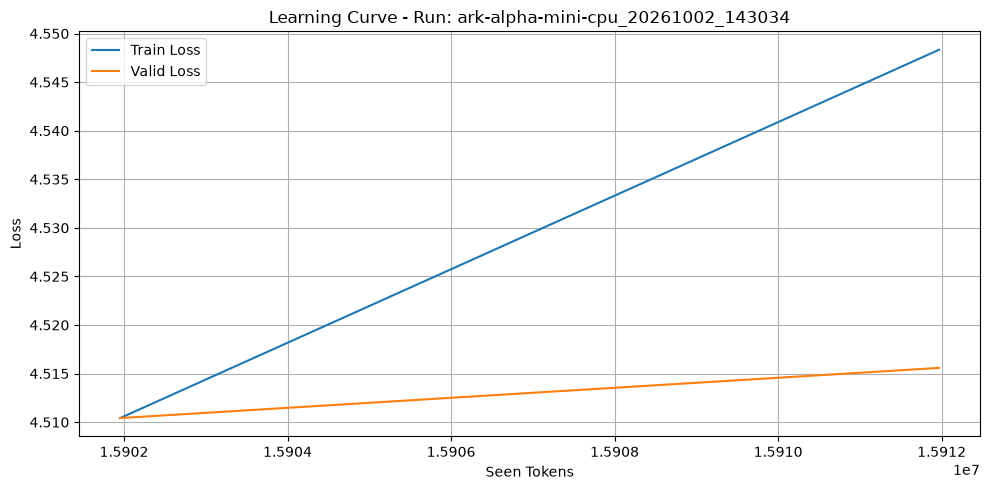



[Sample 1]
 و یادگیری ماشین ماشین و استفاده از برنامه‌نویسی برای ساخت یک برنامه‌نویسی که به داده داده شده هستند.

**مثال:**


Training:   6%|▌         | 20032/338944 [02:50<14:48, 358.76tok/s, B_S=8.75, LR=2.73e-05, Loss=4.5038]   


📊 Train Loss: 4.5038 | Valid Loss: 4.5146
🏆 New Best Model! | Valid Loss: 4.5146 | Previous Best: 4.5156

✅ Model Saved to logs\ark-alpha-mini-cpu_20261002_143034\ark-alpha-mini-v1-2.9M.pt!
✅ Model's Config Saved to logs\ark-alpha-mini-cpu_20261002_143034\config.yaml!


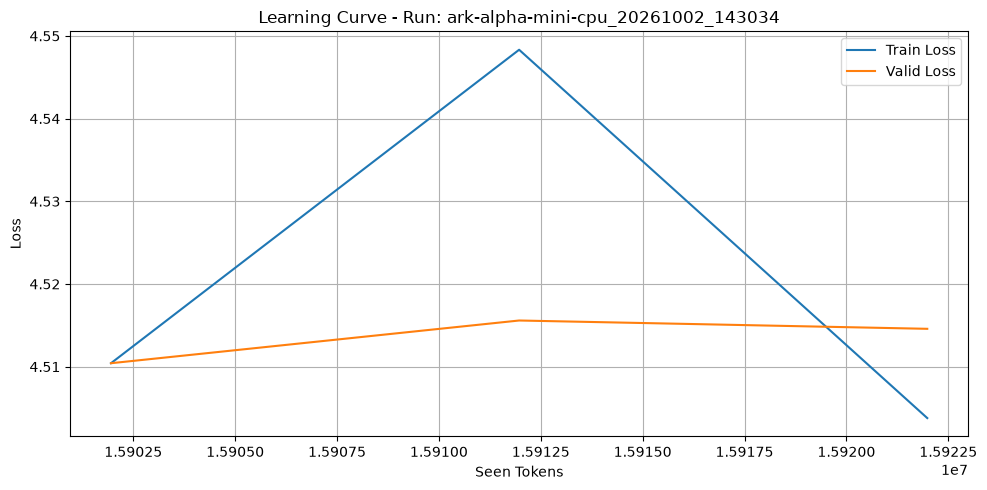



[Sample 1]
 و یادگیری ماشین ماشین و برنامه‌ورک برای استفاده کنید. برای مثال، به‌عنوان: **و برنامه‌نویسی (RE


Training:   9%|▉         | 30048/338944 [05:00<16:38, 309.48tok/s, B_S=7.42, LR=2.73e-05, Loss=4.4596]  


📊 Train Loss: 4.4596 | Valid Loss: 4.5150
⏭️ No improvement | Valid Loss: 4.5150 | Best: 4.5146


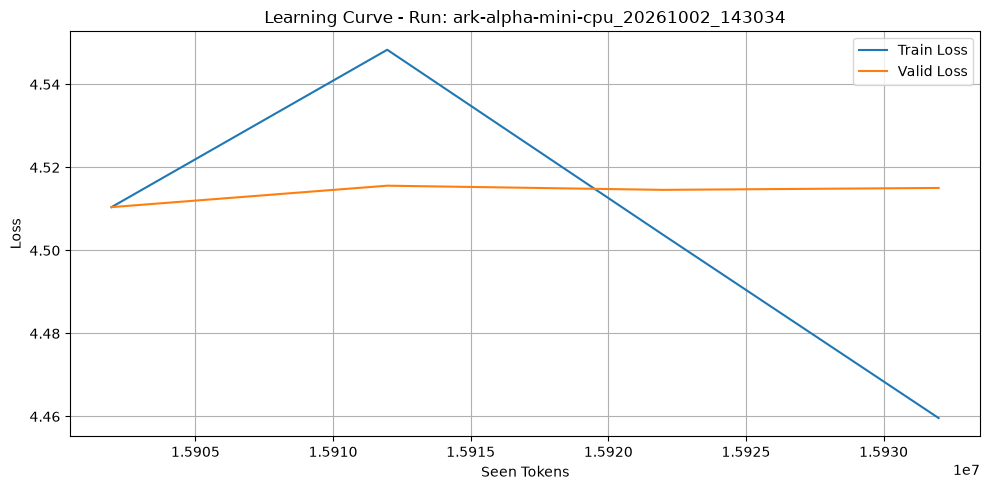



[Sample 1]
 و یادگیری ماشین با یادگیری ماشین و `T, 0: 0 + 0.
3. **1, "A, 2, 0: 1


Training:  12%|█▏        | 40064/338944 [07:11<12:33, 396.70tok/s, B_S=9.47, LR=2.73e-05, Loss=4.4926]   


📊 Train Loss: 4.4926 | Valid Loss: 4.5161
⏭️ No improvement | Valid Loss: 4.5161 | Best: 4.5146


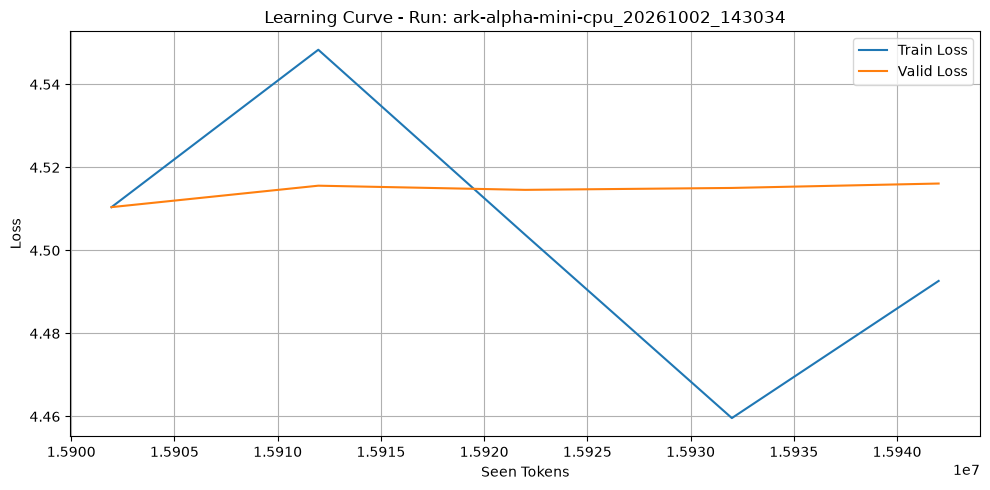



[Sample 1]
 و یادگیری ماشین هستند که در آن را نشان می‌تواند برای استفاده از آن‌ها استفاده می‌شود.
- **ح


Training:  15%|█▍        | 50080/338944 [09:21<12:08, 396.63tok/s, B_S=8.89, LR=2.73e-05, Loss=4.4818]  


📊 Train Loss: 4.4818 | Valid Loss: 4.5126
🏆 New Best Model! | Valid Loss: 4.5126 | Previous Best: 4.5146

✅ Model Saved to logs\ark-alpha-mini-cpu_20261002_143034\ark-alpha-mini-v1-2.9M.pt!
✅ Model's Config Saved to logs\ark-alpha-mini-cpu_20261002_143034\config.yaml!


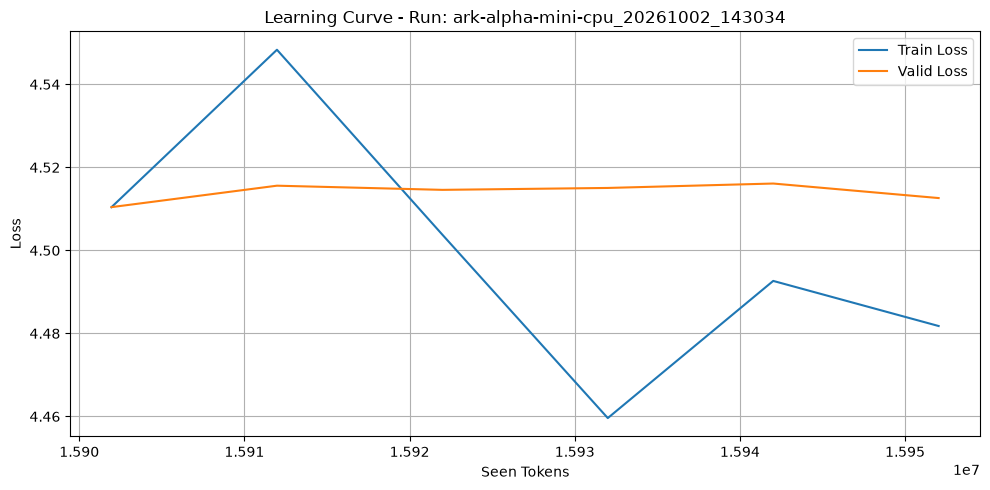



[Sample 1]
 و یادگیری ماشین با یادگیری ماشین و توسعه‌ی عصبی را از داده‌های بزرگ‌ترین ماشین استفاده می‌کند. با


Training:  18%|█▊        | 60096/338944 [11:21<15:57, 291.29tok/s, B_S=8.81, LR=2.73e-05, Loss=4.4800]   


📊 Train Loss: 4.4800 | Valid Loss: 4.5142
⏭️ No improvement | Valid Loss: 4.5142 | Best: 4.5126


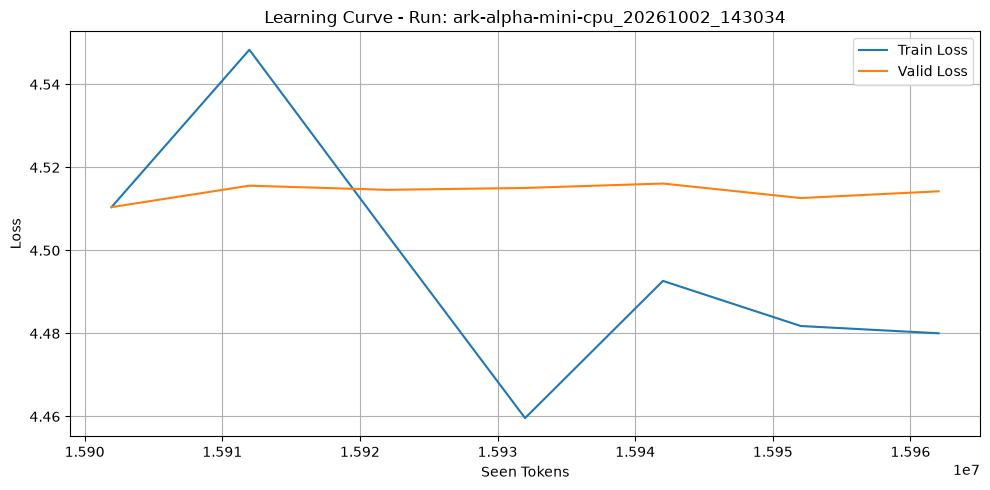



[Sample 1]
 و یادگیری ماشین برای توسعه‌ی داده‌ی استفاده قرار می‌شود. در مدل، به‌طور معمول، داده�


Training:  21%|██        | 70112/338944 [13:41<17:10, 260.75tok/s, B_S=8.29, LR=2.73e-05, Loss=4.4860]  


📊 Train Loss: 4.4860 | Valid Loss: 4.5139
⏭️ No improvement | Valid Loss: 4.5139 | Best: 4.5126


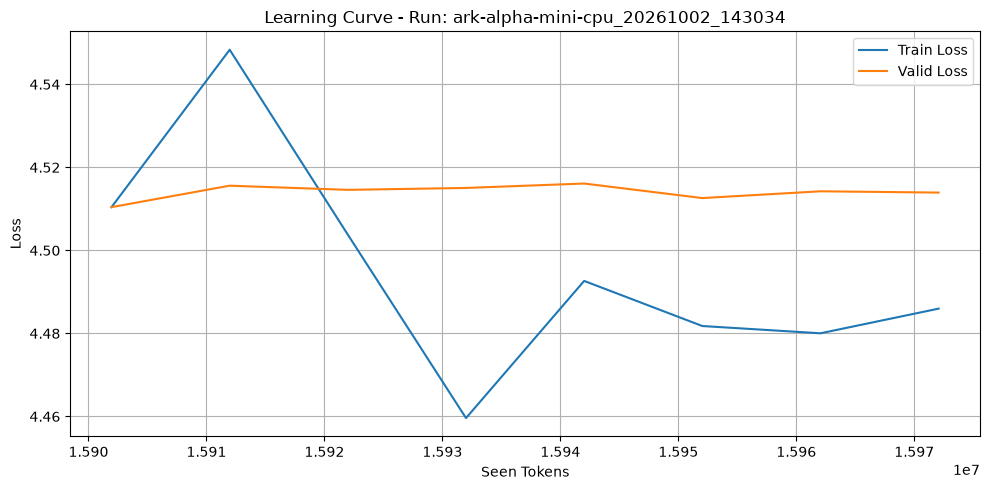



[Sample 1]
 و یادگیری ماشین برای توسعه‌بندی آن است. به‌صورت زیر است:
```javascript
    int 2, 0: **ع |


Training:  24%|██▎       | 80128/338944 [15:51<32:44, 131.72tok/s, B_S=7.87, LR=2.73e-05, Loss=4.4903]  


📊 Train Loss: 4.4903 | Valid Loss: 4.5117
🏆 New Best Model! | Valid Loss: 4.5117 | Previous Best: 4.5126

✅ Model Saved to logs\ark-alpha-mini-cpu_20261002_143034\ark-alpha-mini-v1-2.9M.pt!
✅ Model's Config Saved to logs\ark-alpha-mini-cpu_20261002_143034\config.yaml!


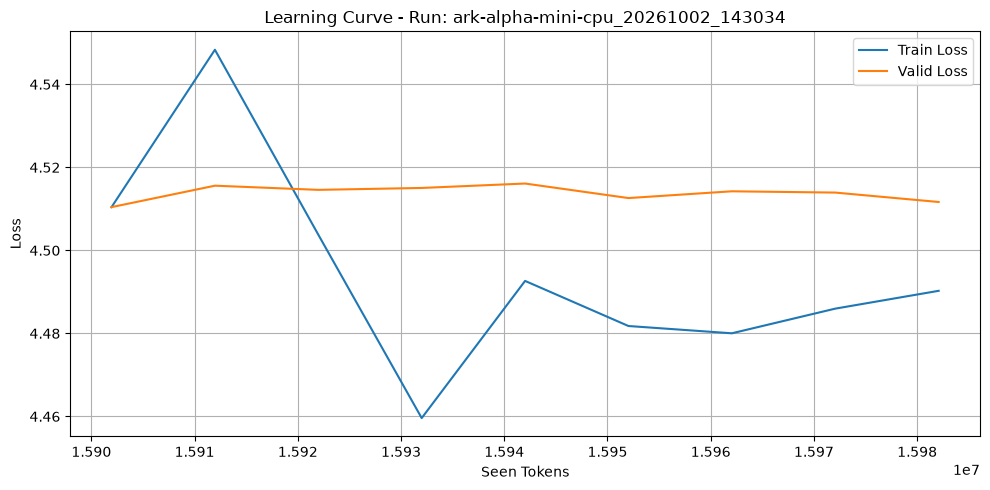



[Sample 1]
 و یادگیری ماشین در این مدل‌ها استفاده می‌شوند.

**تفسیر:**
در نظر می‌توان از الگوریتم با


Training:  27%|██▋       | 90144/338944 [18:11<24:56, 166.21tok/s, B_S=9.33, LR=2.73e-05, Loss=4.4874]   


📊 Train Loss: 4.4874 | Valid Loss: 4.5248
⏭️ No improvement | Valid Loss: 4.5248 | Best: 4.5117


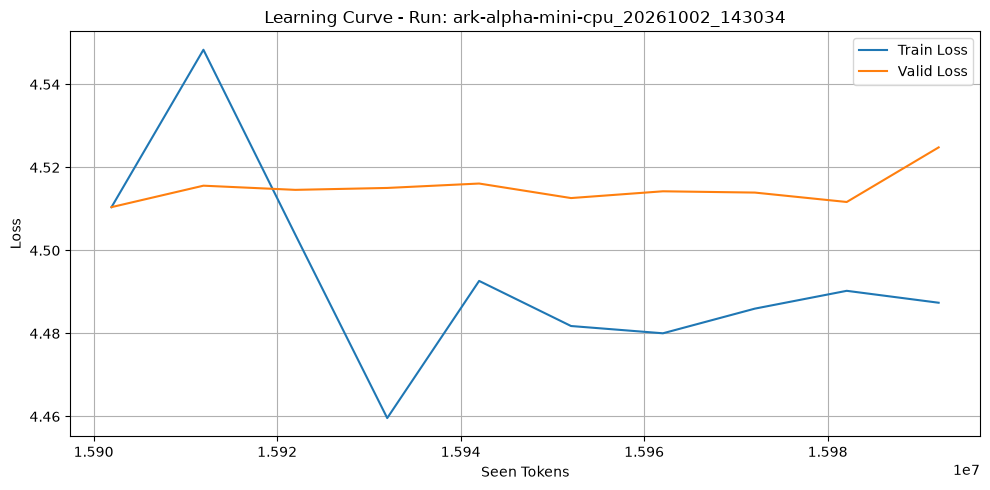



[Sample 1]
 و یادگیری ماشین در این مدل‌ها استفاده می‌شوند.

**تفسیر:**
### یک کتابخانه‌ی `5\)


Training:  30%|██▉       | 100160/338944 [20:32<21:17, 186.84tok/s, B_S=9.10, LR=2.73e-05, Loss=4.4937] 


📊 Train Loss: 4.4937 | Valid Loss: 4.5133
⏭️ No improvement | Valid Loss: 4.5133 | Best: 4.5117


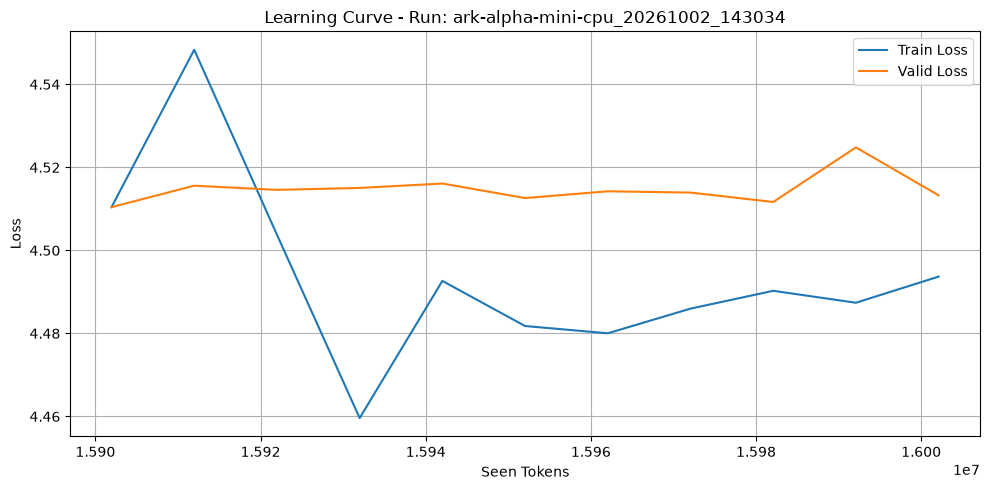



[Sample 1]
 و یادگیری ماشین در زبان ماشین، برنامه‌نویسی و نرم‌افزار و به‌عنوان یک مدل و برنامه‌های اصلی می


Training:  33%|███▎      | 110176/338944 [23:13<16:24, 232.37tok/s, B_S=6.02, LR=2.73e-05, Loss=4.4943]  


📊 Train Loss: 4.4943 | Valid Loss: 4.5144
⏭️ No improvement | Valid Loss: 4.5144 | Best: 4.5117


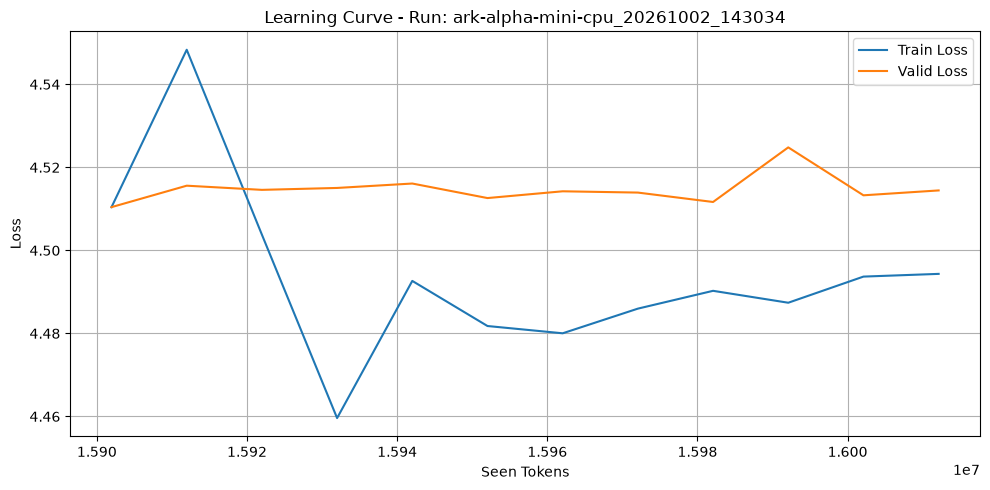



[Sample 1]
 و یادگیری ماشین با زبان ماشین‌ها استفاده می‌شوند.


**مثال:** این است که می‌تواند از برنامه


Training:  35%|███▌      | 120192/338944 [26:28<09:17, 392.04tok/s, B_S=9.45, LR=2.73e-05, Loss=4.4974]   


📊 Train Loss: 4.4974 | Valid Loss: 4.5156
⏭️ No improvement | Valid Loss: 4.5156 | Best: 4.5117


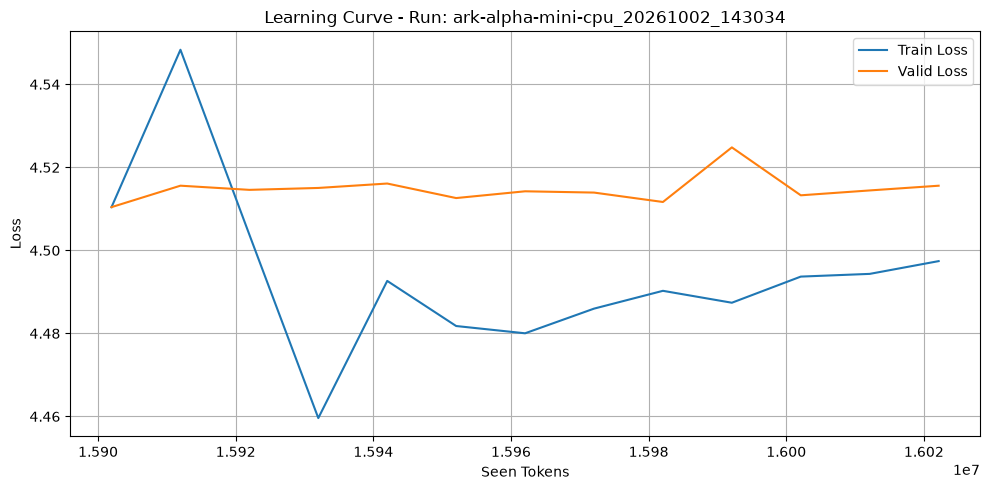



[Sample 1]
 و یادگیری ماشین در آن است که با «عَبَبُمُ الْلِنِمُمُ الْه


Training:  38%|███▊      | 130208/338944 [29:52<14:52, 233.88tok/s, B_S=9.69, LR=2.73e-05, Loss=4.5010]   


📊 Train Loss: 4.5010 | Valid Loss: 4.5171
⏭️ No improvement | Valid Loss: 4.5171 | Best: 4.5117


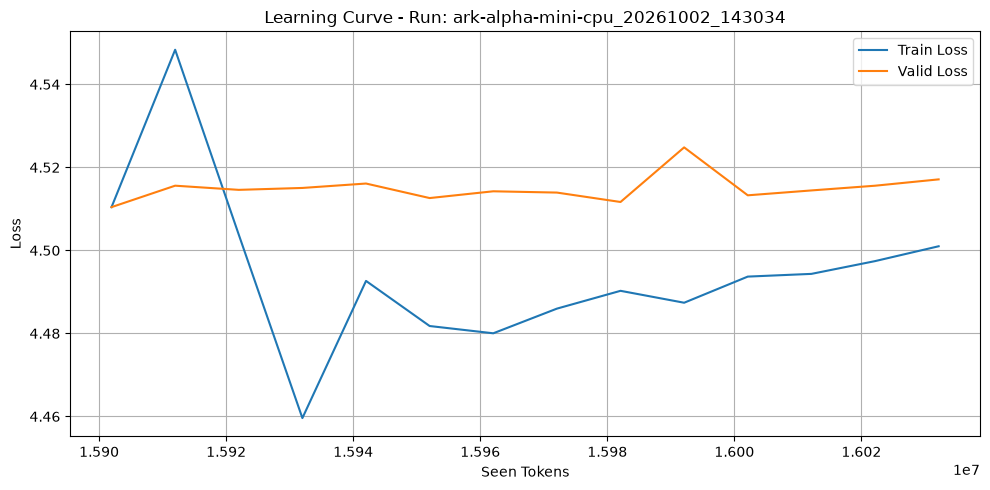



[Sample 1]
 و یادگیری ماشین با زبان ماشین‌های زبانی بزرگ است. برای مثال، مدل‌هایی از داده‌های عصبی مصنوعی در توسعه این


Training:  41%|████▏     | 140224/338944 [32:02<07:57, 416.14tok/s, B_S=8.36, LR=2.73e-05, Loss=4.4997]   


📊 Train Loss: 4.4997 | Valid Loss: 4.5116
🏆 New Best Model! | Valid Loss: 4.5116 | Previous Best: 4.5117

✅ Model Saved to logs\ark-alpha-mini-cpu_20261002_143034\ark-alpha-mini-v1-2.9M.pt!
✅ Model's Config Saved to logs\ark-alpha-mini-cpu_20261002_143034\config.yaml!


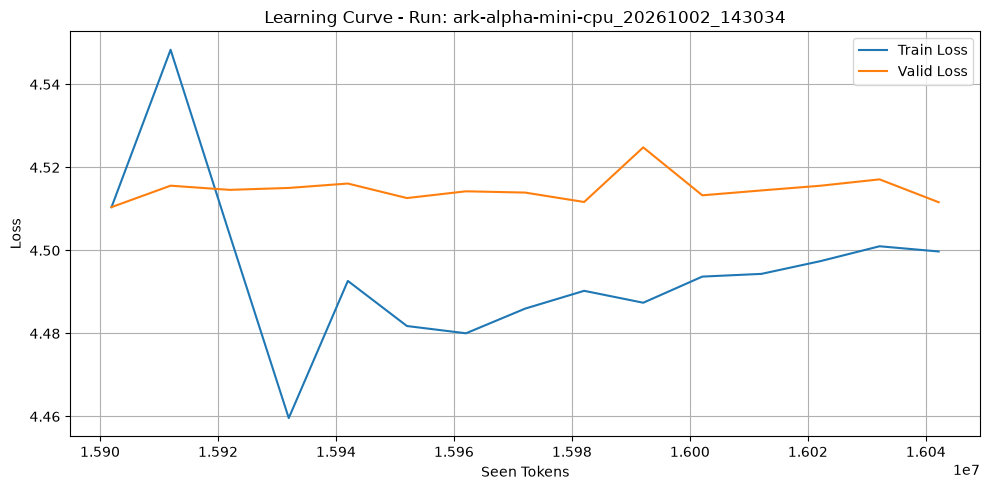



[Sample 1]
 و یادگیری ماشین با زبان ماشین‌های زبانی بزرگ، یک یک برنامه‌نویسی برنامه‌ی وب هستند.

**مثال:**


Training:  44%|████▍     | 150240/338944 [33:52<08:52, 354.51tok/s, B_S=8.32, LR=2.73e-05, Loss=4.4996]   


📊 Train Loss: 4.4996 | Valid Loss: 4.5171
⏭️ No improvement | Valid Loss: 4.5171 | Best: 4.5116


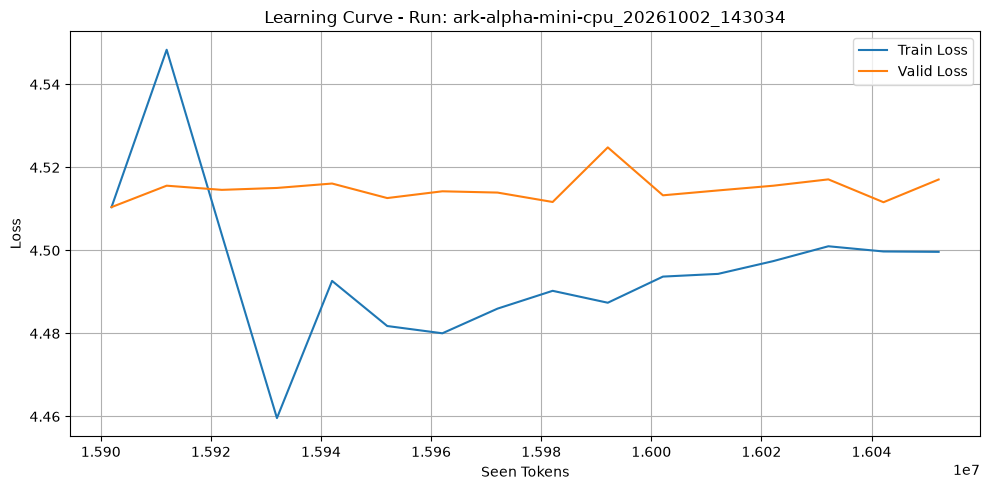



[Sample 1]
، به‌طور مثال، برنامه‌نویسی است که از آن‌ها برای مثال می‌دهد که به‌طور دیگر


Training:  47%|████▋     | 160256/338944 [36:02<09:19, 319.28tok/s, B_S=8.39, LR=2.73e-05, Loss=4.5014]   


📊 Train Loss: 4.5014 | Valid Loss: 4.5150
⏭️ No improvement | Valid Loss: 4.5150 | Best: 4.5116


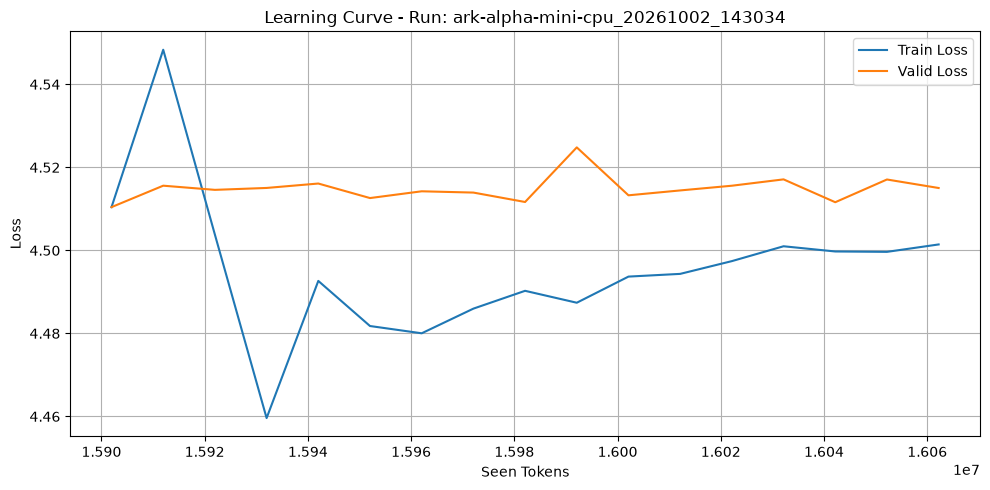



[Sample 1]
 و یادگیری ماشین در مدل‌های اصلی استفاده می‌شوند.

**تفسیر:**
در زبان به‌صورت `3:


Training:  50%|█████     | 170272/338944 [38:23<09:26, 297.55tok/s, B_S=8.21, LR=2.73e-05, Loss=4.5033]  


📊 Train Loss: 4.5033 | Valid Loss: 4.5179
⏭️ No improvement | Valid Loss: 4.5179 | Best: 4.5116


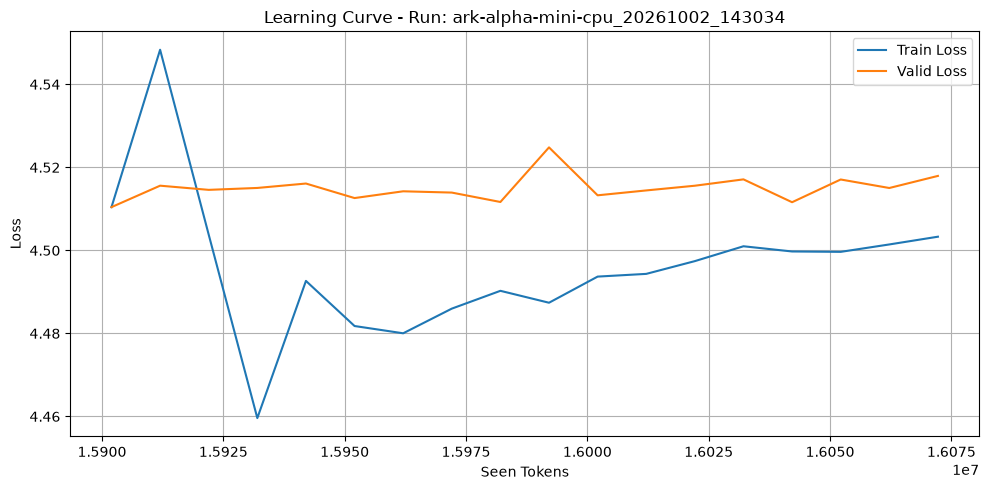



[Sample 1]
 و یادگیری ماشین هستند که می‌دهد به‌عنوان «وَلَتْرُرَلَه» وِ


Training:  53%|█████▎    | 180288/338944 [40:33<07:32, 350.35tok/s, B_S=8.33, LR=2.73e-05, Loss=4.5010]  


📊 Train Loss: 4.5010 | Valid Loss: 4.5133
⏭️ No improvement | Valid Loss: 4.5133 | Best: 4.5116


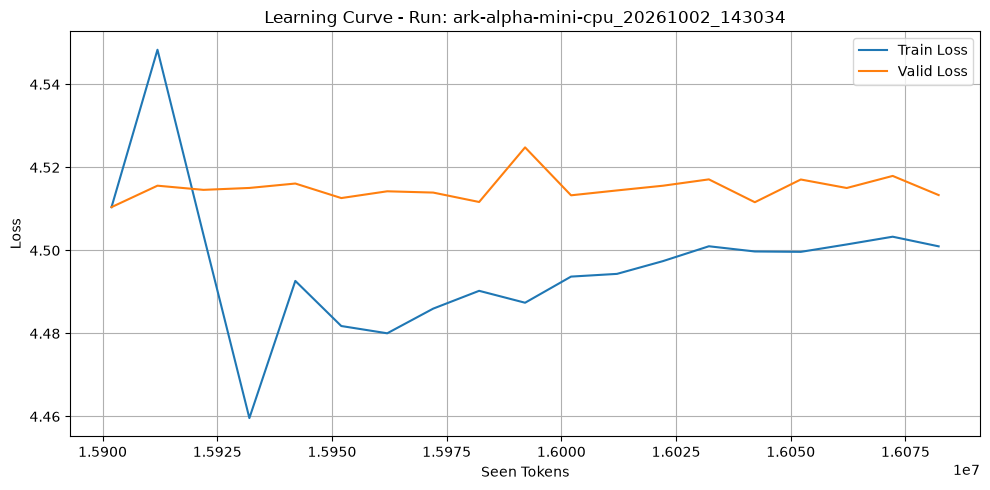



[Sample 1]
 و یادگیری ماشین در این برنامه‌ی یادگیری ماشین و `0` و `3` را می‌کند.

**تفسیر:**


Training:  56%|█████▌    | 190304/338944 [42:43<08:46, 282.33tok/s, B_S=7.87, LR=2.73e-05, Loss=4.5093]  


📊 Train Loss: 4.5093 | Valid Loss: 4.5143
⏭️ No improvement | Valid Loss: 4.5143 | Best: 4.5116


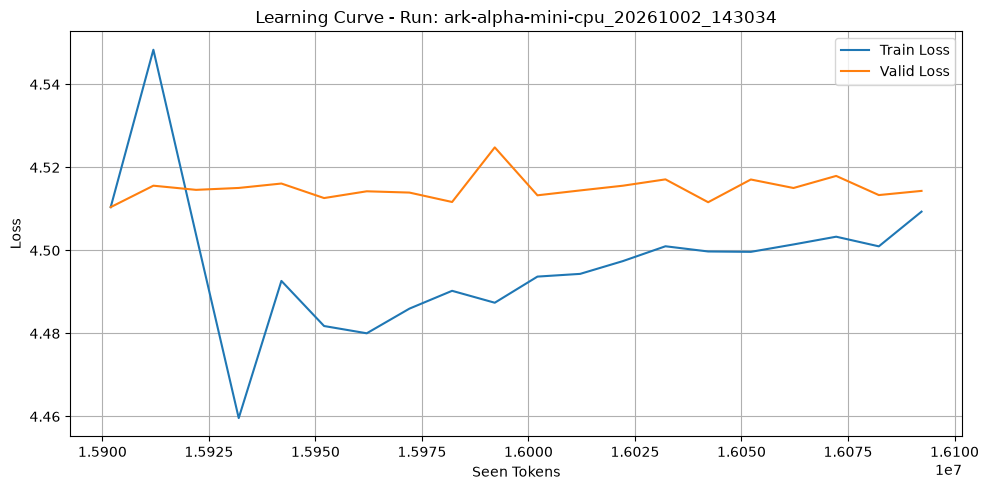



[Sample 1]
 و یادگیری ماشین در این‌عنوان زبان‌هایی که برای استفاده از داده‌ی وب، و از داده‌های اصلیِ


Training:  59%|█████▉    | 200320/338944 [45:03<07:15, 318.52tok/s, B_S=8.92, LR=2.73e-05, Loss=4.5109]   


📊 Train Loss: 4.5109 | Valid Loss: 4.5178
⏭️ No improvement | Valid Loss: 4.5178 | Best: 4.5116


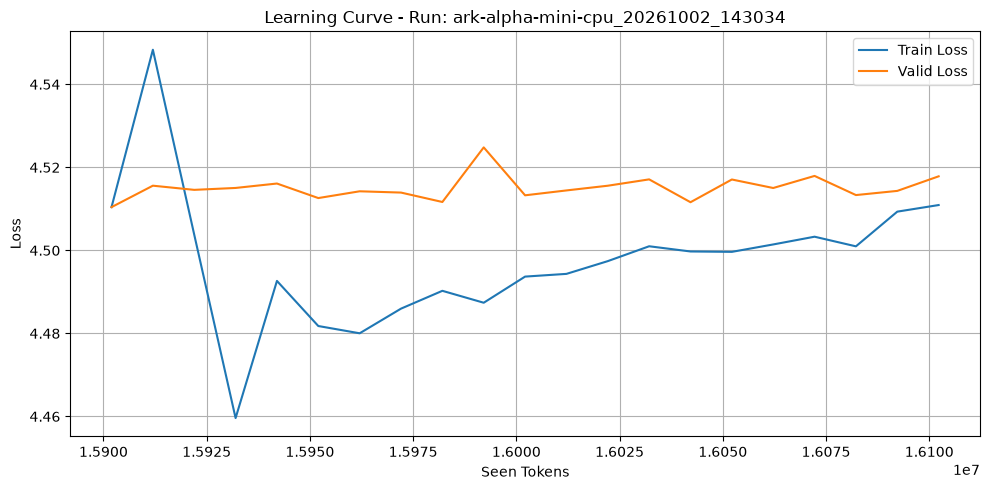



[Sample 1]
 و یادگیری ماشین در این مدل‌ها و برنامه‌ها و برنامه‌های مختلف استفاده کنید. با استفاده از آن‌تر


Training:  62%|██████▏   | 210336/338944 [47:03<06:03, 353.92tok/s, B_S=9.00, LR=2.73e-05, Loss=4.5119]  


📊 Train Loss: 4.5119 | Valid Loss: 4.5100
🏆 New Best Model! | Valid Loss: 4.5100 | Previous Best: 4.5116

✅ Model Saved to logs\ark-alpha-mini-cpu_20261002_143034\ark-alpha-mini-v1-2.9M.pt!
✅ Model's Config Saved to logs\ark-alpha-mini-cpu_20261002_143034\config.yaml!


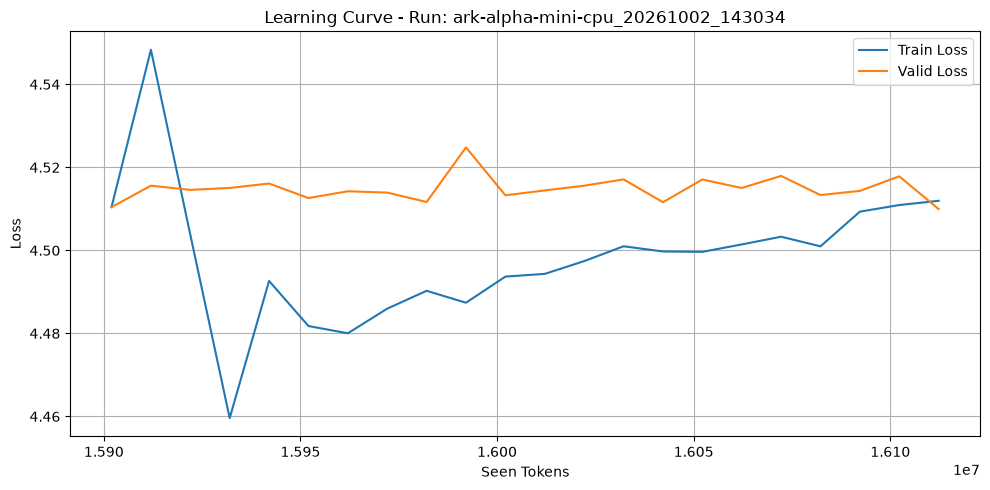



[Sample 1]
‌ها (A)، یک یک نوع از یک مدل) در یک برنامه‌نویسی (S)، داده) است که با استفاده از `


Training:  65%|██████▌   | 220352/338944 [49:33<12:41, 155.75tok/s, B_S=7.79, LR=2.73e-05, Loss=4.5130]  


📊 Train Loss: 4.5130 | Valid Loss: 4.5110
⏭️ No improvement | Valid Loss: 4.5110 | Best: 4.5100


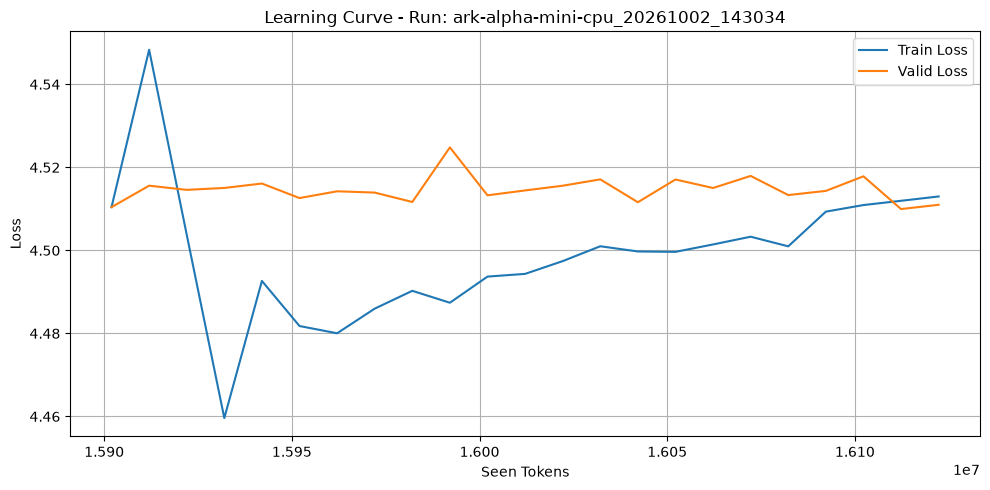



[Sample 1]
 و یادگیری ماشین در یک مدل‌ترین برنامه‌های یادگیری ماشین و برنامه‌سازی داده است. از این‌که‌


Training:  68%|██████▊   | 230368/338944 [51:33<05:13, 345.95tok/s, B_S=8.72, LR=2.73e-05, Loss=4.5129]  

In [ ]:
if train_loader is None or valid_loader is None:

    print(
        "⚠️ Trainer cannot be created because "
        "one of the loaders is None."
    )

else:

    trainer = LLMTrainer(
        model,
        optimizer,
        train_loader,
        valid_loader,
        tokenizer,
        config=cfg
    )

    trainer.optimizer_step = checkpoint_optimizer_step
    trainer.seen_tokens = checkpoint_seen_tokens

    trainer.train()

# 🟢 **Generate**

In [125]:
prompts = [
    'سلام',
    ]

In [126]:
for prompt in prompts:
    # Generate n_rep samples
    gen_continuations = generate(model, tokenizer, prompt, n_rep=3, max_seq_len=32, T=0.9, top_k=10)

    # Display using the chat style function
    print(100*"=")
    display_chat_style(prompt, gen_continuations, tokenizer)
    print(100*".")


[Sample 1]
 (M)) با استفاده از یک‌بندی‌ها می‌کنیم، این سیستم را به‌صورت زیر استفاده می‌

[Sample 2]
 (Ss) است. در ادامه، الگوریتم‌های اصلی این سیستم، به‌طور معمول، به‌صورت یک مدل می�

[Sample 3]
 (Aons) می‌دهد؟ با یک برنامه را یک مدل، از این برنامه‌ی اصلی استفاده قرار می‌شود،
....................................................................................................
